In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'pandas'

In [158]:
df = pd.read_csv(r"C:\Users\Administrador\Downloads\coaster_db.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df

,coaster_name,length,speed,location,status,opening_date,type,manufacturer,height_restriction,model,...,speed1,speed2,speed1_value,speed1_unit,speed_mph,height_value,height_unit,height_ft,inversions_clean,gforce_clean
0,Switchback Railway,600 ft (180 m),6 mph (9.7 km/h),Coney Island,Removed,"June 16, 1884",Wood,LaMarcus Adna Thompson,NaN,Lift Packed,...,6 mph,9.7 km/h,6.0,mph,6.0,50.0,ft,NaN,0,2.9
1,Flip Flap Railway,NaN,NaN,Sea Lion Park,Removed,1895,Wood,Lina Beecher,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),NaN,NaN,"Cleveland, Ohio, United States",Closed,NaN,Other,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1082,American Dreier Looping,"3,444 ft (1,050 m)",53 mph (85 km/h),Other,NaN,NaN,Steel,Anton Schwarzkopf,55 in (140 cm),NaN,...,53 mph,85 km/h,53.0,mph,53.0,111.0,ft,NaN,3,4.7
1083,Pantheon (roller coaster),"3,328 ft (1,014 m)",73 mph (117 km/h),Busch Gardens Williamsburg,Under construction,2022,Steel – Launched,Intamin,NaN,Blitz Coaster,...,73 mph,117 km/h,73.0,mph,73.0,178.0,ft,NaN,2,NaN
1084,Tron Lightcycle Power Run,"3,169.3 ft (966.0 m)",59.3[1] mph (95.4 km/h),Other,NaN,"June 16, 2016",Steel – Launched,Vekoma,4[2] ft (122 cm),Motorbike roller coaster,...,59.3 mph,95.4 km/h,59.3,mph,59.3,78.1,ft,NaN,0,4.0
1085,Tumbili,770 ft (230 m),34 mph (55 km/h),Kings Dominion,Under construction,NaN,Steel – 4th Dimension – Wing Coaster,S&S – Sansei Technologies,NaN,4D Free Spin,...,34 mph,55 km/h,34.0,mph,34.0,112.0,ft,NaN,0,NaN


# Proceso de limpiado de Datos

### Cambio valores de altura y velocidad a numericos quitando las unidades

In [159]:
for col in ['height', 'speed']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.extract(r'(\d+\.?\d*)')
        df[col] = pd.to_numeric(df[col], errors='coerce')


In [160]:
def to_meters(value, unit):
    if pd.isna(value) or pd.isna(unit):
        return np.nan
    if unit == "ft":
        return round(value * 0.3048,2)
    elif unit == "m":
        return value
    else:
        return np.nan  # por si aparece otra cosa inesperada

# Crear nueva columna
df["height_m"] = df.apply(lambda row: to_meters(row["height_value"], row["height_unit"]), axis=1)
df

,coaster_name,length,speed,location,status,opening_date,type,manufacturer,height_restriction,model,...,speed2,speed1_value,speed1_unit,speed_mph,height_value,height_unit,height_ft,inversions_clean,gforce_clean,height_m
0,Switchback Railway,600 ft (180 m),6.0,Coney Island,Removed,"June 16, 1884",Wood,LaMarcus Adna Thompson,NaN,Lift Packed,...,9.7 km/h,6.0,mph,6.0,50.0,ft,NaN,0,2.9,15.24
1,Flip Flap Railway,NaN,NaN,Sea Lion Park,Removed,1895,Wood,Lina Beecher,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12.0,NaN
2,Switchback Railway (Euclid Beach Park),NaN,NaN,"Cleveland, Ohio, United States",Closed,NaN,Other,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
3,Loop the Loop (Coney Island),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN
4,Loop the Loop (Young's Pier),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1082,American Dreier Looping,"3,444 ft (1,050 m)",53.0,Other,NaN,NaN,Steel,Anton Schwarzkopf,55 in (140 cm),NaN,...,85 km/h,53.0,mph,53.0,111.0,ft,NaN,3,4.7,33.83
1083,Pantheon (roller coaster),"3,328 ft (1,014 m)",73.0,Busch Gardens Williamsburg,Under construction,2022,Steel – Launched,Intamin,NaN,Blitz Coaster,...,117 km/h,73.0,mph,73.0,178.0,ft,NaN,2,NaN,54.25
1084,Tron Lightcycle Power Run,"3,169.3 ft (966.0 m)",59.3,Other,NaN,"June 16, 2016",Steel – Launched,Vekoma,4[2] ft (122 cm),Motorbike roller coaster,...,95.4 km/h,59.3,mph,59.3,78.1,ft,NaN,0,4.0,23.80
1085,Tumbili,770 ft (230 m),34.0,Kings Dominion,Under construction,NaN,Steel – 4th Dimension – Wing Coaster,S&S – Sansei Technologies,NaN,4D Free Spin,...,55 km/h,34.0,mph,34.0,112.0,ft,NaN,0,NaN,34.14


### Consulto y filtro filas y columnas no validas

In [161]:
print(f"Tenemos {df.duplicated().sum()} filas duplicadas")

Tenemos 0 filas duplicadas


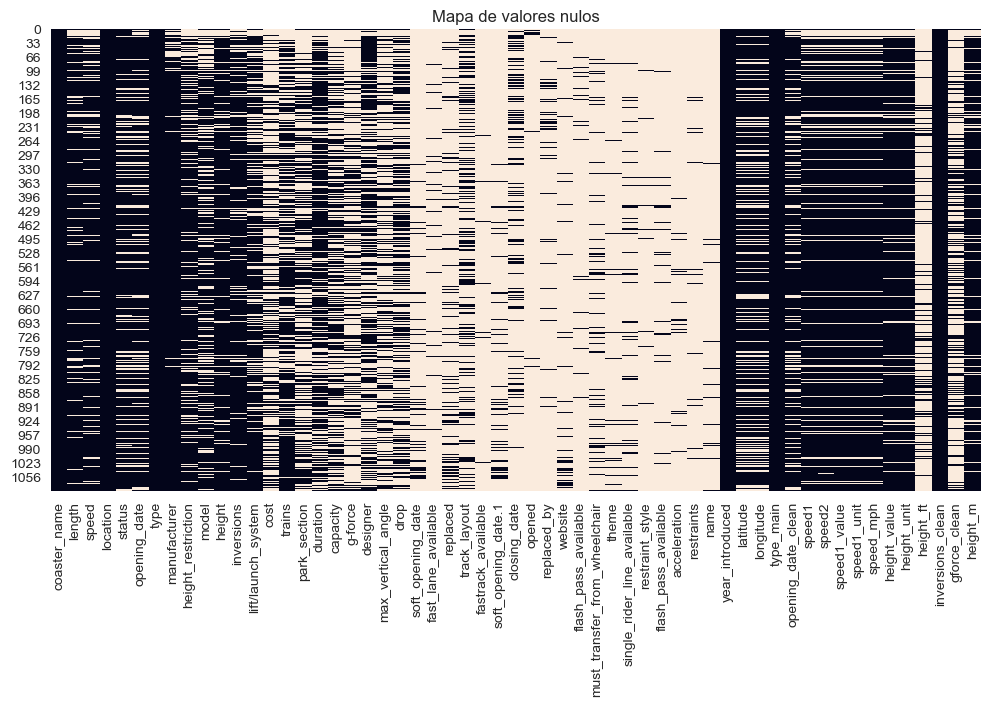

In [162]:
# Heatmap de nulos
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

In [163]:
df_aeliminar = df.isnull().sum().sort_values(ascending=False).head(10)
print(df_aeliminar)
df_Limpio = df.drop(columns = list(df_aeliminar.index))
registrosMalos = (df.isnull().sum(axis=1) / df.shape[1]).sort_values(ascending=False).head(10).round(2)
df_Limpio = df_Limpio.drop(index=registrosMalos.index)
df_Limpio = df_Limpio.drop(index= 905)


fastrack_available      1068
restraint_style         1065
restraints              1063
opened                  1060
name                    1052
theme                   1043
flash_pass_available    1041
flash_pass_available    1037
acceleration            1027
fast_lane_available     1018
dtype: int64


### Mapa de valores nulos dsp de borar top 10 filas y columnas con mas nulos

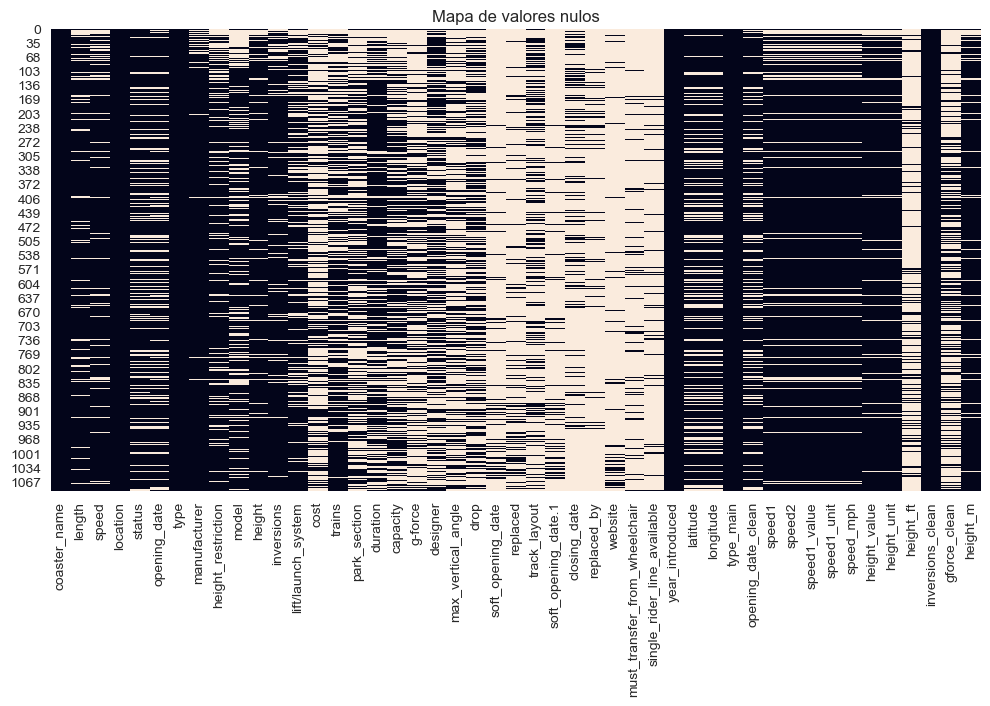

In [164]:
plt.figure(figsize=(12,6))
sns.heatmap(df_Limpio.isnull(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

### Mapa de valores nulos despues de borrar columnas con mas de 50% de valores nulos / Ultimo filtrado

Columnas eliminadas por nulos altos: 16


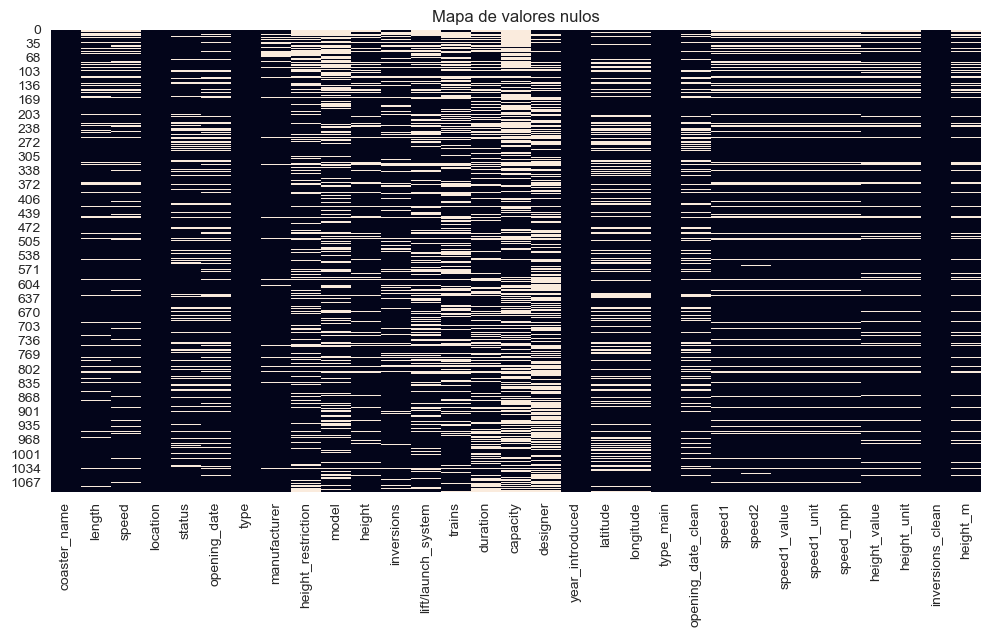

In [165]:
column_nulos = df_Limpio.isnull().mean() > 0.5
print(f"Columnas eliminadas por nulos altos: {column_nulos.sum()}")
df_Limpio = df_Limpio.drop(columns=df_Limpio.columns[column_nulos])

plt.figure(figsize=(12,6))
sns.heatmap(df_Limpio.isnull(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

### Despues filtro y mantengo unicamente las columnas que utilizare en las visualizaciones para manener ordenado el dataset

In [172]:
df_Limpio = df_Limpio[['coaster_name', 'height_m', 'speed_mph','year_introduced', 'inversions']]
cols_sucio = set(col.strip().lower() for col in df.columns)
cols_limpio = set(col.strip().lower() for col in df_Limpio.columns)
cols_eliminadas = cols_sucio - cols_limpio
print("Columnas eliminadas:")
for col in cols_eliminadas:
    print(col)
df_Limpio

Columnas eliminadas:
longitude
status
flash_pass_available
theme
speed1
replaced
single_rider_line_available
height_unit
drop
capacity
cost
max_vertical_angle
restraint_style
model
height_value
lift/launch_system
fastrack_available
height_restriction
duration
must_transfer_from_wheelchair
trains
manufacturer
soft_opening_date
name
speed1_value
type
opened
restraints
g-force
speed2
acceleration
replaced_by
opening_date_clean
speed1_unit
fast_lane_available
soft_opening_date.1
park_section
gforce_clean
location
speed
closing_date
height
opening_date
designer
latitude
track_layout
type_main
inversions_clean
length
website
height_ft


,coaster_name,height_m,speed_mph,year_introduced,inversions
0,Switchback Railway,15.24,6.0,1884,NaN
1,Flip Flap Railway,NaN,NaN,1895,1.0
2,Switchback Railway (Euclid Beach Park),NaN,NaN,1896,NaN
3,Loop the Loop (Coney Island),NaN,NaN,1901,1.0
4,Loop the Loop (Young's Pier),NaN,NaN,1901,1.0
...,...,...,...,...,...
1082,American Dreier Looping,33.83,53.0,2022,3.0
1083,Pantheon (roller coaster),54.25,73.0,2022,2.0
1084,Tron Lightcycle Power Run,23.80,59.3,2022,0.0
1085,Tumbili,34.14,34.0,2022,0.0


# Graficado de Datos

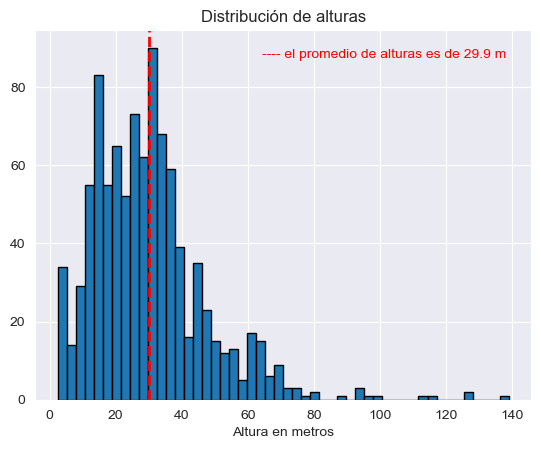

count    964.000000
mean      29.919803
std       17.464556
min        2.440000
25%       17.070000
50%       28.040000
75%       36.580000
max      138.990000
Name: height_m, dtype: float64

In [167]:

if 'height_m' in df_Limpio.columns:
    plt.hist(df_Limpio['height_m'].dropna(), bins=50, edgecolor='k')
    plt.title("Distribución de alturas")
    plt.xlabel("Altura en metros")
    valor_marcar = df_Limpio['height_m'].mean()
    plt.xticks(rotation = 0)
    plt.axvline(x=valor_marcar, color='red', linestyle='--', linewidth=2, label=f"Altiura Promedio = {valor_marcar}     ")
    plt.text(
        0.95, 0.95,
        f"---- el promedio de alturas es de {valor_marcar:.1f} m",
        transform=plt.gca().transAxes,
        ha="right", va="top",
        fontsize=10, color="red"
    )
    plt.show()
df_Limpio['height_m'].describe()

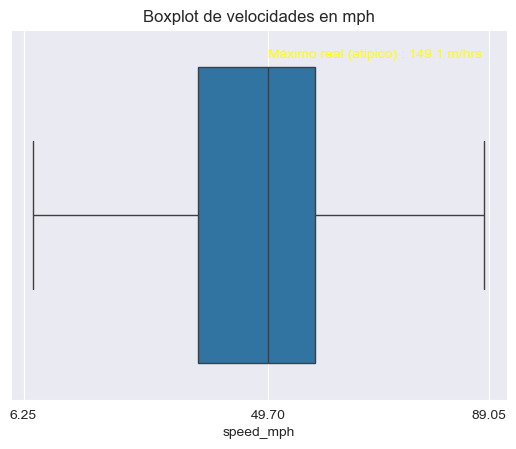

Montanas rusas con velocidad anormal (de menor a mayor)


,coaster_name,speed_mph
132,Lil' Thunder,5.0
0,Switchback Railway,6.0
166,Wilderness Run,6.0
815,Intimidator 305,90.0
1051,Orion (roller coaster),91.0
870,Leviathan (Canada's Wonderland),92.0
540,Millennium Force,93.0
553,Steel Dragon 2000,95.0
941,Fury 325,95.0
903,Ring Racer,99.4


In [168]:
q1 = df_Limpio['speed_mph'].quantile(0.25)
q3 = df_Limpio['speed_mph'].quantile(0.75)
irq = q3 - q1
if 'speed_mph' in df_Limpio.columns:
    sns.boxplot(x=df_Limpio['speed_mph'], showfliers= False)
    plt.title("Boxplot de velocidades en mph")
    plt.xticks([( q1 - 1.5 * (irq)),df_Limpio['speed_mph'].median(),( q3 + 1.5 * (irq))])
    plt.text(
    0.95, 0.95,
    f"Máximo real (atipico) : {df_Limpio['speed_mph'].max()} m/hrs",
    transform=plt.gca().transAxes,
    ha="right", va="top",
    fontsize=10, color="yellow"
)
    plt.show()
vel_anormal_Mayor = df_Limpio.loc[df_Limpio['speed_mph'] > ( q3 + 1.5 * (irq)), ['coaster_name', 'speed_mph']]
vel_anormal_Menor = df_Limpio.loc[df_Limpio['speed_mph'] < ( q1 - 1.5 * (irq)), ['coaster_name', 'speed_mph']]
vel_anormal = pd.concat([vel_anormal_Menor, vel_anormal_Mayor], axis=0)
print('Montanas rusas con velocidad anormal (de menor a mayor)')
vel_anormal.sort_values(by='speed_mph', ascending=True, inplace=True)
vel_anormal


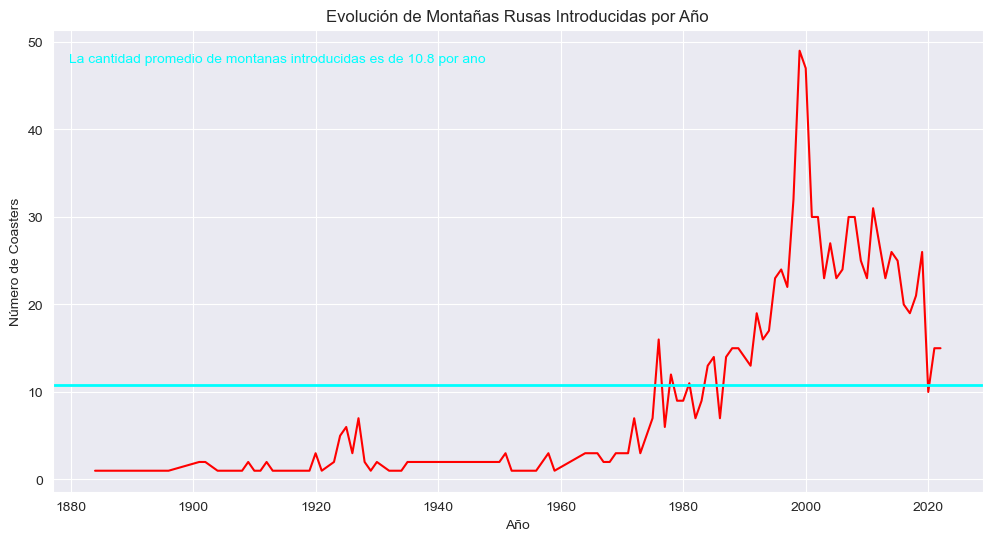

In [169]:
coasters_por_ano = df_Limpio['year_introduced'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
promedio_coasters = coasters_por_ano.mean()
coasters_por_ano.plot(kind='line', color='red', label='Coasters por año')
plt.axhline(y=promedio_coasters, color='cyan', linestyle='-', linewidth=2, label=f'Promedio = {promedio_coasters:.2f}')
plt.title('Evolución de Montañas Rusas Introducidas por Año')
plt.xlabel('Año')
plt.ylabel('Número de Coasters')
plt.text(
    0.47, 0.95,
    f"La cantidad promedio de montanas introducidas es de {coasters_por_ano.mean():.1f} por ano ",
    transform=plt.gca().transAxes,
    ha="right", va="top",
    fontsize=10, color="cyan"
)
plt.show()

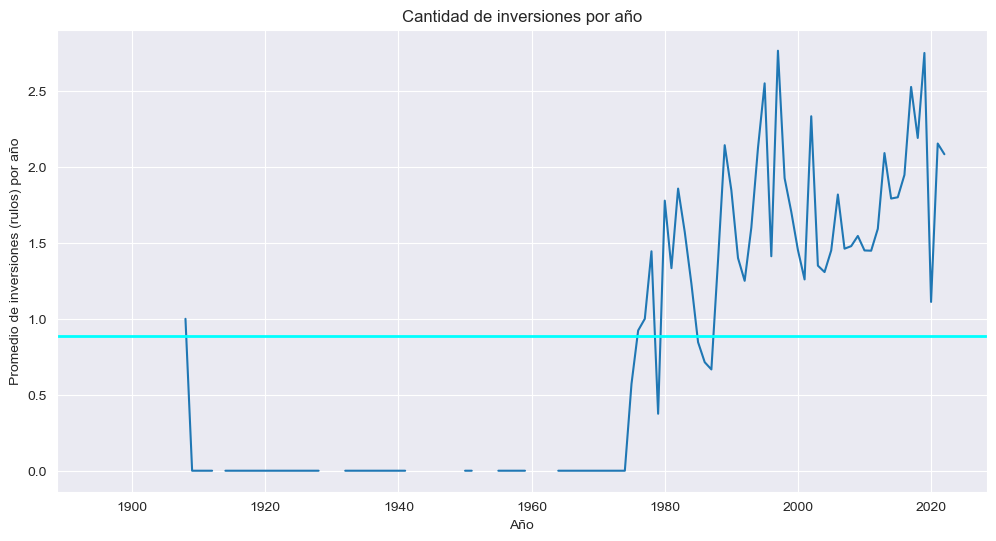

In [170]:
conteo = df.groupby("year_introduced")["inversions"].mean()
plt.figure(figsize=(12, 6))
plt.plot(conteo.index, conteo.values)
plt.xlabel("Año")
plt.ylabel("Promedio de inversiones (rulos) por año")
plt.axhline(y=conteo.mean(), color='cyan', linestyle='-', linewidth=2, label=f'Promedio = {promedio_coasters:.2f}')
plt.title("Cantidad de inversiones por año")
plt.grid(True)
plt.show()